# Machine Learning Model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Dataset reading
#at_risk_diabetes is output(categories)

diabetes = pd.read_csv(r"C:\Users\KIIT0001\Desktop\ML_Project\Mini_project_ML\Diabetes_dataset_cleaned.csv")
diabetes

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,low,0,0,1
1,71,26.786882,125.964887,low,0,0,0
2,48,20.977319,61.876196,moderate,1,1,0
3,34,27.959924,137.648074,low,0,0,0
4,62,28.304175,65.879564,moderate,0,0,0
...,...,...,...,...,...,...,...
99989,74,28.001900,130.147993,low,0,0,0
99990,26,32.514707,141.784172,low,0,1,1
99991,71,26.504374,66.520077,moderate,0,0,0
99992,62,31.735351,105.753990,high,1,0,1


In [4]:
#displays the unique values only 
for i in diabetes.columns:
    print(i,':','\n',diabetes[i].unique(),'\n') 

age : 
 [58 71 48 34 62 27 40 77 38 42 30 43 72 55 59 22 41 21 63 49 57 79 52 31
 44 68 46 78 61 47 35 66 70 74 76 56 26 28 37 23 33 69 45 39 54 36 25 73
 53 29 50 67 64 60 20 24 32 51 75 65] 

bmi : 
 [33.15481565 26.78688161 20.97731911 ... 26.50437356 31.73535116
 30.62711346] 

glucose_level : 
 [ 71.04986701 125.96488728  61.8761961  ...  66.52007708 105.75399037
  81.91640046] 

physical_activity_level : 
 ['low' 'moderate' 'high'] 

family_history : 
 [0 1] 

smoker : 
 [0 1] 

at_risk_diabetes : 
 [1 0] 



In [5]:
# Encoding physical activity level to 0 1 2
# Label encoder can't be used as this randomly assigns the values according to alphabetical order(h,l,m)
# OrdinalEncoder requires a 2D input. So the feature is passed as a DataFrame using double brackets

from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories = [['low','moderate','high']]) #order is written in categories

In [6]:
# Encoding transformation applied(as 2D so [[]])
diabetes[['physical_activity_level']] = oe.fit_transform(diabetes[['physical_activity_level']]) 

In [7]:
diabetes.physical_activity_level.unique()

array([0., 1., 2.])

In [8]:
# converts our data from float type[0. ,1. , 2.] to integer
diabetes['physical_activity_level'] = diabetes['physical_activity_level'].astype(int)

In [9]:
diabetes.physical_activity_level.unique() 

array([0, 1, 2])

In [10]:
diabetes.head()

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,0,0,0,1
1,71,26.786882,125.964887,0,0,0,0
2,48,20.977319,61.876196,1,1,1,0
3,34,27.959924,137.648074,0,0,0,0
4,62,28.304175,65.879564,1,0,0,0


In [11]:
diabetes['physical_activity_level'].dtype

dtype('int32')

In [12]:
# input output creation
ip = diabetes.drop('at_risk_diabetes',axis=1) #axis = 1 drops a column from input , axis = 0 drops row
op = diabetes.at_risk_diabetes # can also write diabetes[at risk diabetes]

In [13]:
# Training & Testing Split
# 80% training data , rest 20% testing data (test_siz=0.2)
# random_state used to fix the values otherwise everytime we run it takes different training and testing data 

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ip,op,test_size=0.2,random_state=3)

In [14]:
#prints number of training and testing samples
# x_train(input) and y_train(output) are the  samples used to train the model for input and output
# x_test used for prediction of output and that is compared with original output stored in y_test

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(79995, 6)
(79995,)
(19999, 6)
(19999,)


In [15]:
# Standard Scaler Transform

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

### Applying Logistic Regression 

In [16]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [17]:
#predict() generates predicted class labels for unseen test data using the trained model
pred = lr.predict(x_test)
pred

array([0, 0, 1, ..., 1, 0, 0], dtype=int64)

In [18]:
y_test

91271    0
32663    0
45546    1
6064     0
79008    0
        ..
37416    0
36201    0
30377    0
81085    0
16356    0
Name: at_risk_diabetes, Length: 19999, dtype: int64

#### Accuracy using Confusion Matrix

In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc = accuracy_score(pred,y_test)
re = recall_score(pred,y_test)
pr = precision_score(pred,y_test)
f1 = f1_score(pred,y_test)

print('Accuracy:',acc)
print('Recall:',re)
print('Precision:',pr)
print('F1-Score:',f1)

Accuracy: 0.8532426621331066
Recall: 0.7098871022921656
Precision: 0.49855838539163866
F1-Score: 0.5857445306986592


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_mat = confusion_matrix(pred,y_test)
conf_mat

array([[14989,  2087],
       [  848,  2075]], dtype=int64)

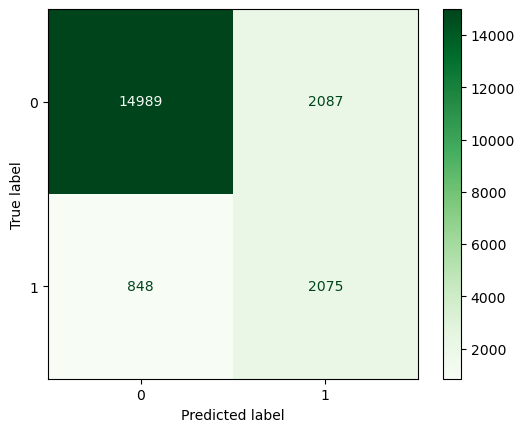

In [21]:
cmd = ConfusionMatrixDisplay(conf_mat)
cmd.plot(cmap = 'Greens')
plt.show()

### Applying SVM (Support Vector Classfier)

In [ ]:
# kernel rbf(radial basis function) creates curved decision boundary for better fit of non linear cols(BMI,glucose)
# gamma controls influence of each data point(0.01 is low so smooth and wide decision boundary), less sensitive to noise
# C controls penalty for mis-classification (1000 is high so less chance of errors and tries to classify all data point correct)

from sklearn.svm import SVC
svc = SVC(kernel='rbf',gamma=0.01,C=1000)
svc.fit(x_train,y_train)

In [ ]:
pred1 = svc.predict(x_test)
pred1

In [ ]:
y_test

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc = accuracy_score(pred1, y_test)
re = recall_score(pred1, y_test)
pr = precision_score(pred1, y_test)
f1 = f1_score(pred1, y_test)

print('Accuracy:',acc)
print('Recall:',re)
print('Precision:',pr)
print('F1-Score:',f1)

# Applying Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
diabetes

,age,bmi,glucose_level,physical_activity_level,family_history,smoker,at_risk_diabetes
0,58,33.154816,71.049867,0,0,0,1
1,71,26.786882,125.964887,0,0,0,0
2,48,20.977319,61.876196,1,1,1,0
3,34,27.959924,137.648074,0,0,0,0
4,62,28.304175,65.879564,1,0,0,0
...,...,...,...,...,...,...,...
99989,74,28.001900,130.147993,0,0,0,0
99990,26,32.514707,141.784172,0,0,1,1
99991,71,26.504374,66.520077,1,0,0,0
99992,62,31.735351,105.753990,2,1,0,1


In [25]:
X = diabetes.drop("at_risk_diabetes", axis=1)
y = diabetes["at_risk_diabetes"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
rf = RandomForestClassifier(n_estimators = 100,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [32]:
pred2 = rf.predict(X_test)
pred2

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [34]:
print('Accuracy:',accuracy_score(y_test,pred2))
print('Recall:',recall_score(y_test,pred2))
print('Precision:',precision_score(y_test,pred2))
print('F1 Score:',f1_score(y_test,pred2))

Accuracy: 0.9111955597779889
Recall: 0.7461685823754789
Precision: 0.8131524008350731
F1 Score: 0.7782217782217782


In [35]:
confusion_mat = confusion_matrix(y_test,pred2)
confusion_mat

array([[15107,   716],
       [ 1060,  3116]], dtype=int64)

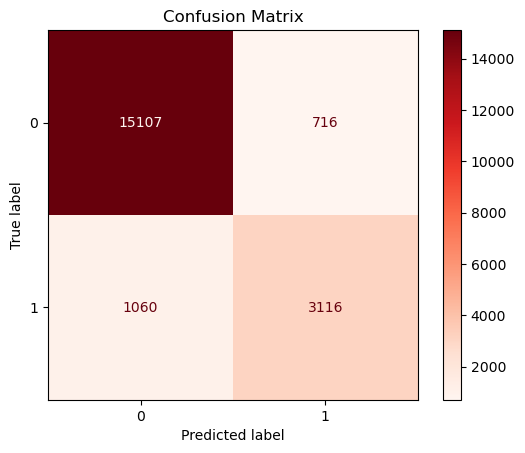

In [41]:
cmd = ConfusionMatrixDisplay(confusion_mat)
cmd.plot(cmap = 'Reds')
plt.title('Confusion Matrix')
plt.show()

In [39]:
from sklearn.metrics import classification_report
print('Classification Report:',classification_report(y_test,pred2))

Classification Report:               precision    recall  f1-score   support

           0       0.93      0.95      0.94     15823
           1       0.81      0.75      0.78      4176

    accuracy                           0.91     19999
   macro avg       0.87      0.85      0.86     19999
weighted avg       0.91      0.91      0.91     19999



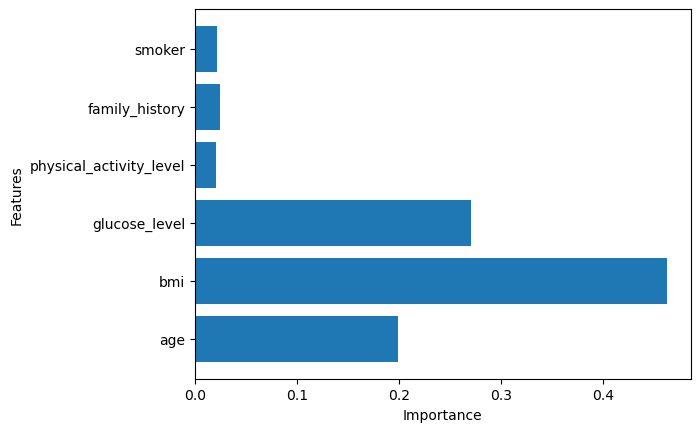

In [42]:
#It shows the importance of each attribute in finding the output

import matplotlib.pyplot as plt

feature_importance = rf.feature_importances_
features = X.columns

plt.barh(features, feature_importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()